# Demo 08 - Local-vol diagnostics, PDE repricing, and convergence

This notebook builds local volatility from the smoothed implied-surface handoff, inspects reliability diagnostics before pricing, validates the PDE stack on an anchor problem, and reprices a quote grid while keeping error and runtime trade-offs visible.

- inspect local-vol validity and denominator diagnostics
- validate the PDE solver on an anchor case
- reprice under local vol on the quote grid
- inspect convergence and runtime trade-offs

`PROFILE = "quick"` keeps the notebook compact; switch to `PROFILE = "full"` for broader sweeps.

In [ ]:
# ruff: noqa: E402
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'option_pricing').exists():
            return candidate
    return start

ROOT = _find_repo_root(Path.cwd())
SRC = ROOT / 'src'
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PROFILE = 'quick'
SEED = 7

,profile,input_surface_type,repricing_target_surface_type,n_repricing_strikes,n_repricing_expiries
0,quick,ESSVISmoothedSurface,ESSVISmoothedSurface,6,5


In [ ]:
import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
from IPython.display import display  # noqa: E402

from option_pricing.demos import (  # noqa: E402
    build_essvi_bridge_artifacts,
    build_localvol_pde_demo_artifacts,
    build_shared_demo_scenario,
    build_surface_demo_artifacts,
)
from option_pricing.diagnostics.vol_surface import plot as vs_plot  # noqa: E402

pd.set_option('display.max_columns', None)

scenario = build_shared_demo_scenario(profile=PROFILE, seed=SEED)
surface_art = build_surface_demo_artifacts(
    profile=PROFILE,
    seed=SEED,
    scenario=scenario,
)
bridge_art = build_essvi_bridge_artifacts(
    profile=PROFILE,
    seed=SEED,
    scenario=scenario,
    surface_artifacts=surface_art,
)
art = build_localvol_pde_demo_artifacts(
    profile=PROFILE,
    seed=SEED,
    scenario=scenario,
    bridge_artifacts=bridge_art,
)

headline = pd.DataFrame(
    [
        {
            'profile': art.profile,
            'input_surface_type': art.meta['input_surface_type'],
            'repricing_target_surface_type': art.meta['repricing_target_surface_type'],
            'n_repricing_strikes': len(art.meta['repricing_strikes']),
            'n_repricing_expiries': len(art.meta['repricing_expiries']),
        }
    ]
)
display(headline)

## 1) Inspect local-vol diagnostics before pricing

The local-vol report, invalid regions, and worst points are shown first so pricing results can be read with the construction diagnostics in view.

,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.208672,0.277583,0.30931,0.547313


,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.208563,0.283886,0.357416,0.455086


,status,count
0,clean quick-profile diagnostic grid,0


,rank,T,y,K,denom,local_var,sigma,invalid,reasons
0,1,0.12,-0.30,74.259832,0.455086,0.127746,0.357416,False,
1,2,0.12,-0.29,75.006156,0.461865,0.124504,0.352851,False,
2,3,0.12,-0.28,75.759980,0.469067,0.121267,0.348234,False,
3,4,0.12,-0.27,76.521381,0.476729,0.118036,0.343564,False,
4,5,0.12,-0.26,77.290433,0.484892,0.114812,0.338839,False,
5,6,0.12,-0.25,78.067215,0.493601,0.111595,0.334058,False,
6,7,0.12,-0.24,78.851804,0.502908,0.108387,0.329222,False,
7,8,0.12,-0.23,79.644277,0.512867,0.105189,0.324328,False,
8,9,0.12,0.30,135.310236,0.518530,0.108718,0.329723,False,
9,10,0.12,-0.22,80.444716,0.523541,0.102003,0.319379,False,


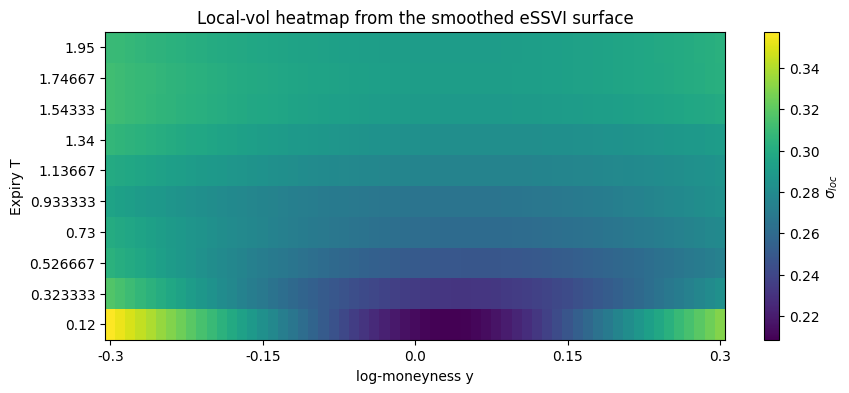

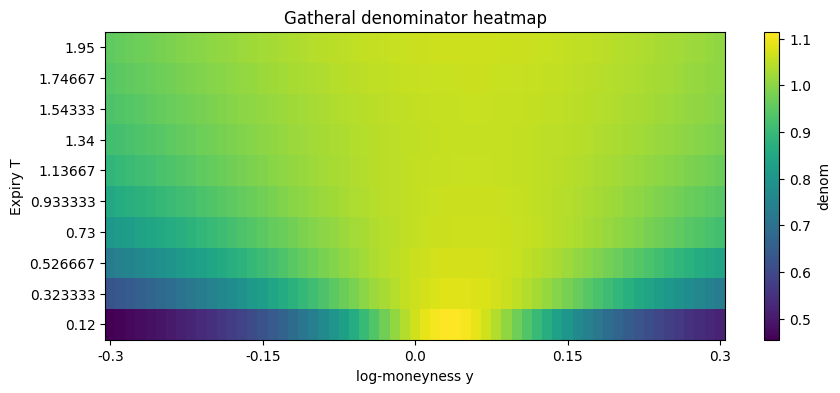

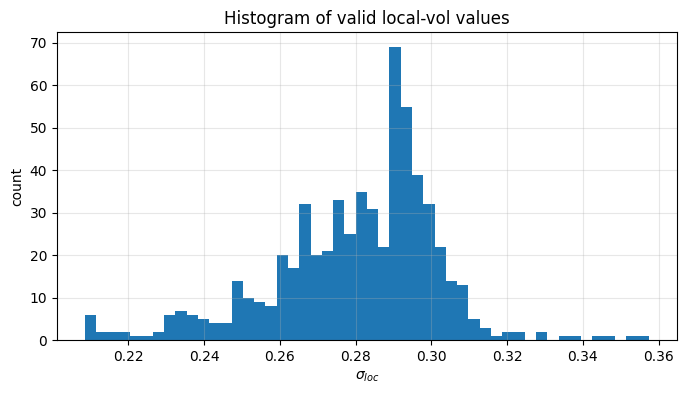

In [2]:
reason_counts = art.tables['localvol_reason_counts']
if reason_counts.empty:
    reason_counts = pd.DataFrame(
        [{'status': 'clean quick-profile diagnostic grid', 'count': 0}]
    )

display(art.bridge.tables['essvi_localvol_handoff_summary'])
display(art.tables['localvol_summary'])
display(reason_counts)
display(art.tables['localvol_worst_points'].head(10))

lv_rep = art.reports['lv_rep']
vs_plot.plot_localvol_heatmap(
    lv_rep,
    kind='sigma',
    title='Local-vol heatmap from the smoothed eSSVI surface',
)
vs_plot.plot_localvol_heatmap(
    lv_rep,
    kind='denom',
    mask_invalid=False,
    title='Gatheral denominator heatmap',
)
vs_plot.plot_localvol_histogram(
    lv_rep,
    title='Histogram of valid local-vol values',
)


## 2) Validate the PDE stack on an anchor case

A simple anchor problem makes the solver baseline easy to read before the notebook returns to the full local-vol repricing loop.

In [3]:
display(art.tables['pde_anchor_grouped'])
display(art.tables['pde_anchor_frontier'])

frontier = art.tables['pde_anchor_frontier'].copy()
if len(frontier) > 1:
    plt.figure(figsize=(7, 4))
    plt.scatter(frontier['runtime_ms'], frontier['abs_err'], s=55)
    for row in frontier.itertuples(index=False):
        plt.annotate(f'Nx={row.Nx}, Nt={row.Nt}', (row.runtime_ms, row.abs_err))
    plt.xlabel('Runtime (ms)')
    plt.ylabel('Absolute error')
    plt.title('PDE anchor frontier')
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print('Quick profile anchor frontier has a single point; switch to PROFILE="full" for a richer frontier plot.')


,method,advection,Nx,Nt,n,abs_err_mean,abs_err_max,runtime_ms_mean,feasible_rate
0,rannacher,central,101,201,1,0.000002,0.000002,83.7982,1.0


,contract,kind,payout,tau,spot,strike,sigma,r,q,sweep,coord,method,advection,spacing,Nx,Nt,ic_remedy,runtime_ms,analytic,pde,err,abs_err,rel_err,x0,feasible,within_budget,feasible_and_within_budget,score,domain_n_sigma
0,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,logS,rannacher,central,uniform,101,201,cell_avg,83.7982,0.482634,0.482637,0.000002,0.000002,0.000004,4.60517,True,True,True,83.7982,5.0


Quick profile anchor frontier has a single point; switch to PROFILE="full" for a richer frontier plot.


## 3) Reprice under local vol and inspect convergence

The repricing tables and convergence sweep keep pricing accuracy, error concentration, and runtime trade-offs visible on the same grid.

,n_options,mean_abs_price_error,max_abs_price_error,mean_abs_iv_error_bp,max_abs_iv_error_bp,mean_runtime_ms,total_runtime_ms,Nx,Nt
0,30,0.403512,1.219317,342.219695,1028.471031,890.291877,26793.7314,101,201


,T,K,target_iv,pde_iv,abs_iv_error_bp,target_price,pde_price,abs_price_error,runtime_ms
2,0.15,97.000000,0.218399,0.126587,918.121139,5.219321,4.000004,1.219317,678.7749
3,0.15,104.333333,0.207070,0.122019,850.510208,1.638639,0.545211,1.093428,679.4202
8,0.25,97.000000,0.222618,0.174155,484.634254,6.322061,5.433052,0.889009,815.4679
9,0.25,104.333333,0.215397,0.168846,465.507861,2.731109,1.856103,0.875006,836.7907
15,0.50,104.333333,0.229663,0.206940,227.226912,5.060938,4.425614,0.635324,951.3872
14,0.50,97.000000,0.233462,0.211586,218.752430,8.622740,8.039529,0.583211,944.8625
7,0.25,89.666667,0.235872,0.185047,508.245074,11.766963,11.238350,0.528613,823.4436
10,0.25,111.666667,0.214527,0.170867,436.602363,0.973600,0.471582,0.502019,827.9817
16,0.50,111.666667,0.228767,0.208308,204.592462,2.770248,2.280430,0.489818,958.7153
21,1.00,104.333333,0.249034,0.237615,114.195029,8.928446,8.473074,0.455372,989.8299


,Nx,Nt,grid_points,pde_price,target_price,abs_error,runtime_ms
0,101,201,20301,9.482389,9.92812,0.445731,987.7163
1,151,301,45451,9.485606,9.92812,0.442514,1483.5539
2,201,401,80601,9.486811,9.92812,0.441309,2037.0296


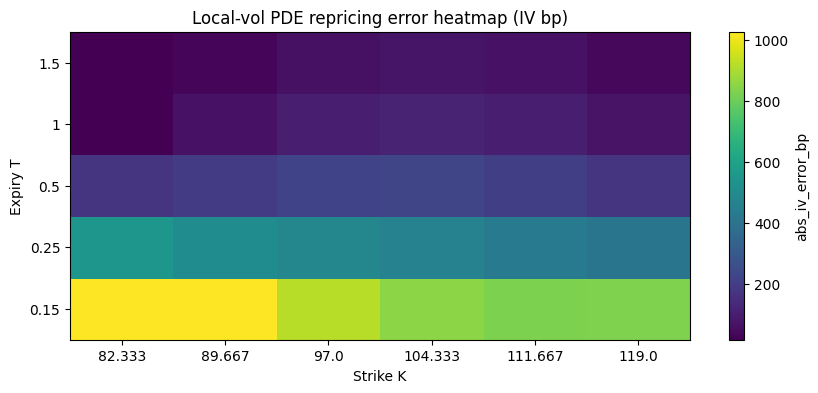

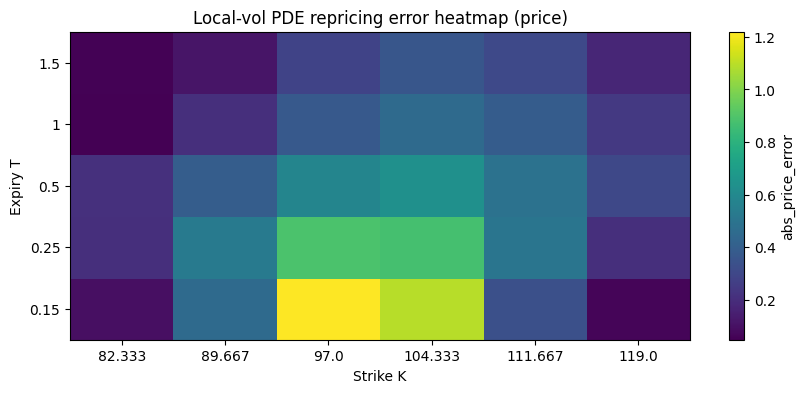

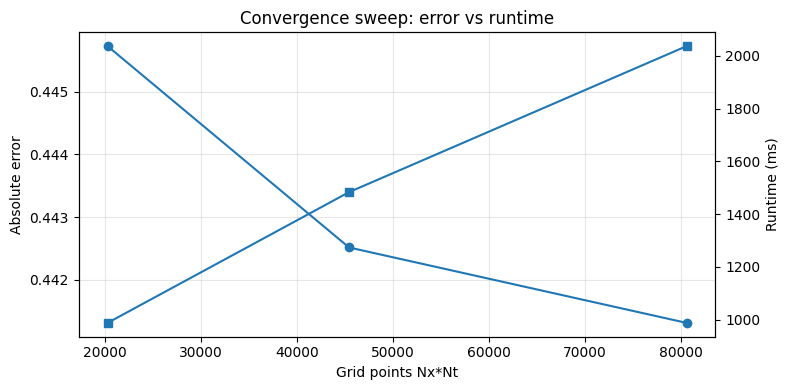

In [4]:
repricing = art.tables['repricing_grid'].copy()
worst_repricing = repricing.sort_values('abs_price_error', ascending=False).head(10)

display(art.tables['repricing_summary'])
display(
    worst_repricing[
        [
            'T',
            'K',
            'target_iv',
            'pde_iv',
            'abs_iv_error_bp',
            'target_price',
            'pde_price',
            'abs_price_error',
            'runtime_ms',
        ]
    ]
)
display(art.tables['convergence_grid'])

vs_plot.plot_repricing_heatmap(
    repricing,
    value_col='abs_iv_error_bp',
    title='Local-vol PDE repricing error heatmap (IV bp)',
)
vs_plot.plot_repricing_heatmap(
    repricing,
    value_col='abs_price_error',
    title='Local-vol PDE repricing error heatmap (price)',
)

conv = art.tables['convergence_grid'].copy()
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(conv['grid_points'], conv['abs_error'], marker='o', label='abs error')
ax1.set_xlabel('Grid points Nx*Nt')
ax1.set_ylabel('Absolute error')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(conv['grid_points'], conv['runtime_ms'], marker='s', label='runtime')
ax2.set_ylabel('Runtime (ms)')

ax1.set_title('Convergence sweep: error vs runtime')
fig.tight_layout()
plt.show()

## Key outputs

- local-vol diagnostic summary, invalid-point review, and denominator checks
- PDE anchor error/runtime table and frontier
- repricing summary, worst rows, and error heatmaps
- convergence table for grid refinement trade-offs